# Experiment 001 — Baseline Random Forest

**Goal:** Establish a baseline using raw features + minimal cleaning. No feature engineering yet.


In [1]:
import sys
print(sys.executable)

/Users/cedrictay/Documents/end_to_end_ml_pipeline/.venv-1/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import shap

pd.set_option('display.max_columns', None)
%matplotlib inline

## 1. Load Data

In [3]:
df = pd.read_csv('../../data/raw/train.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Inspect & Quick Summary Checks

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Null counts and percentages
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
null_summary[null_summary.null_count > 0]

,null_count,null_pct
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


In [7]:
# Class balance
print('Target distribution:')
print(df['Survived'].value_counts())
print(f"\nSurvival rate: {df['Survived'].mean():.2%}")

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.38%


In [8]:
# Duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


## 3. Structural Cleaning

In [9]:
# Only drop the row identifier — it carries no signal
df = df.drop(columns=['PassengerId'])
print(f'Remaining columns: {list(df.columns)}')

Remaining columns: ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [10]:
# --- Name ---
# Format: 'Lastname, Title. Firstname ...'
print('Name samples:')
print(df['Name'].head(10).to_string())
print(f'\nUnique names: {df["Name"].nunique()} / {len(df)} rows')
print(f'Any duplicates: {df["Name"].duplicated().sum()}')

# Extract title to see what's embedded
df['Name_title'] = df['Name'].str.extract(r',\s*([^.]+)\.')
print('\nTitle value counts:')
print(df['Name_title'].value_counts())

Name samples:
0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)

Unique names: 891 / 891 rows
Any duplicates: 0

Title value counts:
Name_title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dty

In [11]:
# --- Ticket ---
# Mixed format: some are pure numeric, some have a prefix string
print('Ticket samples:')
print(df['Ticket'].head(20).to_string())
print(f'\nUnique tickets: {df["Ticket"].nunique()} / {len(df)} rows')

# Check if tickets are shared across passengers (group travel)
ticket_counts = df['Ticket'].value_counts()
print(f'\nTickets shared by >1 passenger: {(ticket_counts > 1).sum()}')
print('\nTop shared tickets:')
print(ticket_counts[ticket_counts > 1].head(10))

# Check format: numeric-only vs prefix
df['Ticket_is_numeric'] = df['Ticket'].str.match(r'^\d+$')
print(f'\nNumeric-only tickets: {df["Ticket_is_numeric"].sum()}')
print(f'Prefixed tickets:     {(~df["Ticket_is_numeric"]).sum()}')

Ticket samples:
0            A/5 21171
1             PC 17599
2     STON/O2. 3101282
3               113803
4               373450
5               330877
6                17463
7               349909
8               347742
9               237736
10             PP 9549
11              113783
12           A/5. 2151
13              347082
14              350406
15              248706
16              382652
17              244373
18              345763
19                2649

Unique tickets: 681 / 891 rows

Tickets shared by >1 passenger: 134

Top shared tickets:
Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
349909          4
347077          4
Name: count, dtype: int64

Numeric-only tickets: 661
Prefixed tickets:     230


In [12]:
# --- Cabin ---
# Format: letter (deck) + number — but 77% missing
print('Cabin samples (non-null):')
print(df['Cabin'].dropna().head(20).to_string())
print(f'\nNull: {df["Cabin"].isnull().sum()} / {len(df)} ({df["Cabin"].isnull().mean():.1%})')
print(f'Unique values: {df["Cabin"].nunique()}')

# Deck letter distribution
df['Cabin_deck'] = df['Cabin'].str[0]
print('\nDeck distribution:')
print(df['Cabin_deck'].value_counts())

# Survival rate by deck
print('\nSurvival rate by deck:')
print(df.groupby('Cabin_deck')['Survived'].mean().sort_values(ascending=False))

Cabin samples (non-null):
1             C85
3            C123
6             E46
10             G6
11           C103
21            D56
23             A6
27    C23 C25 C27
31            B78
52            D33
54            B30
55            C52
61            B28
62            C83
66            F33
75          F G73
88    C23 C25 C27
92            E31
96             A5
97        D10 D12

Null: 687 / 891 (77.1%)
Unique values: 147

Deck distribution:
Cabin_deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

Survival rate by deck:
Cabin_deck
D    0.757576
E    0.750000
B    0.744681
F    0.615385
C    0.593220
G    0.500000
A    0.466667
T    0.000000
Name: Survived, dtype: float64


## 4. EDA — Numerical Columns

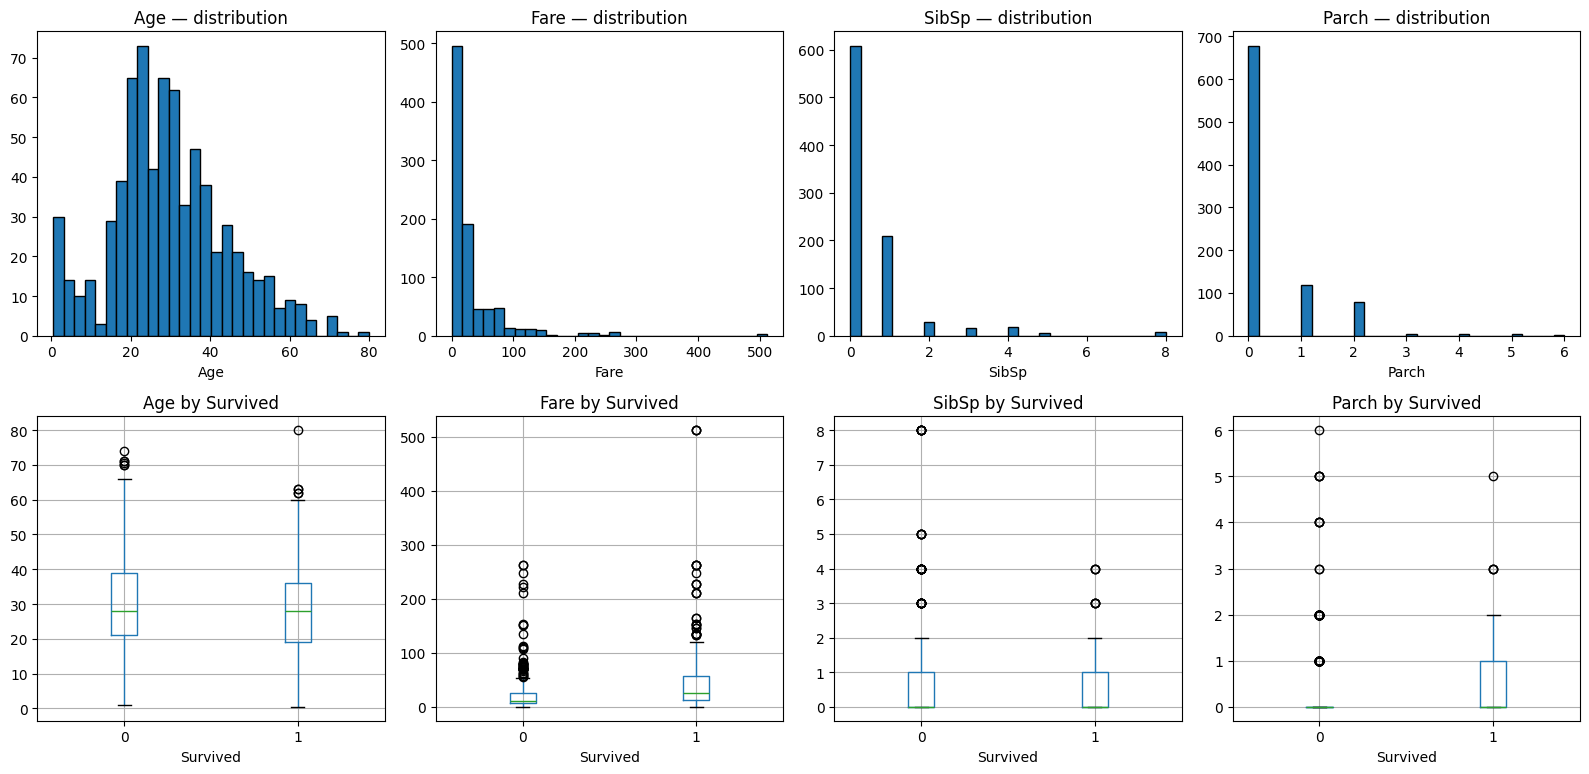

In [13]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, len(num_cols), figsize=(16, 8))

for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[0, i].set_title(f'{col} — distribution')
    axes[0, i].set_xlabel(col)

    df.boxplot(column=col, by='Survived', ax=axes[1, i])
    axes[1, i].set_title(f'{col} by Survived')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [14]:
# Correlation with target
print('Correlation with Survived:')
print(df[num_cols + ['Survived']].corr()['Survived'].drop('Survived').sort_values())

Correlation with Survived:
Age     -0.077221
SibSp   -0.035322
Parch    0.081629
Fare     0.257307
Name: Survived, dtype: float64


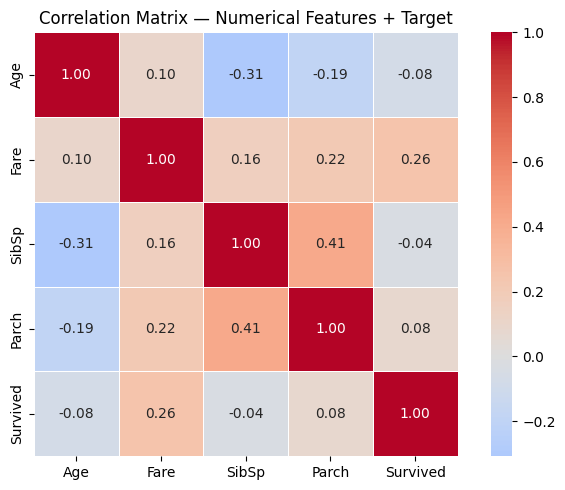

In [28]:
# Correlation matrix among numerical columns (including target)
corr_cols = num_cols + ['Survived']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features + Target')
plt.tight_layout()
plt.show()

## 5. EDA — Categorical Columns

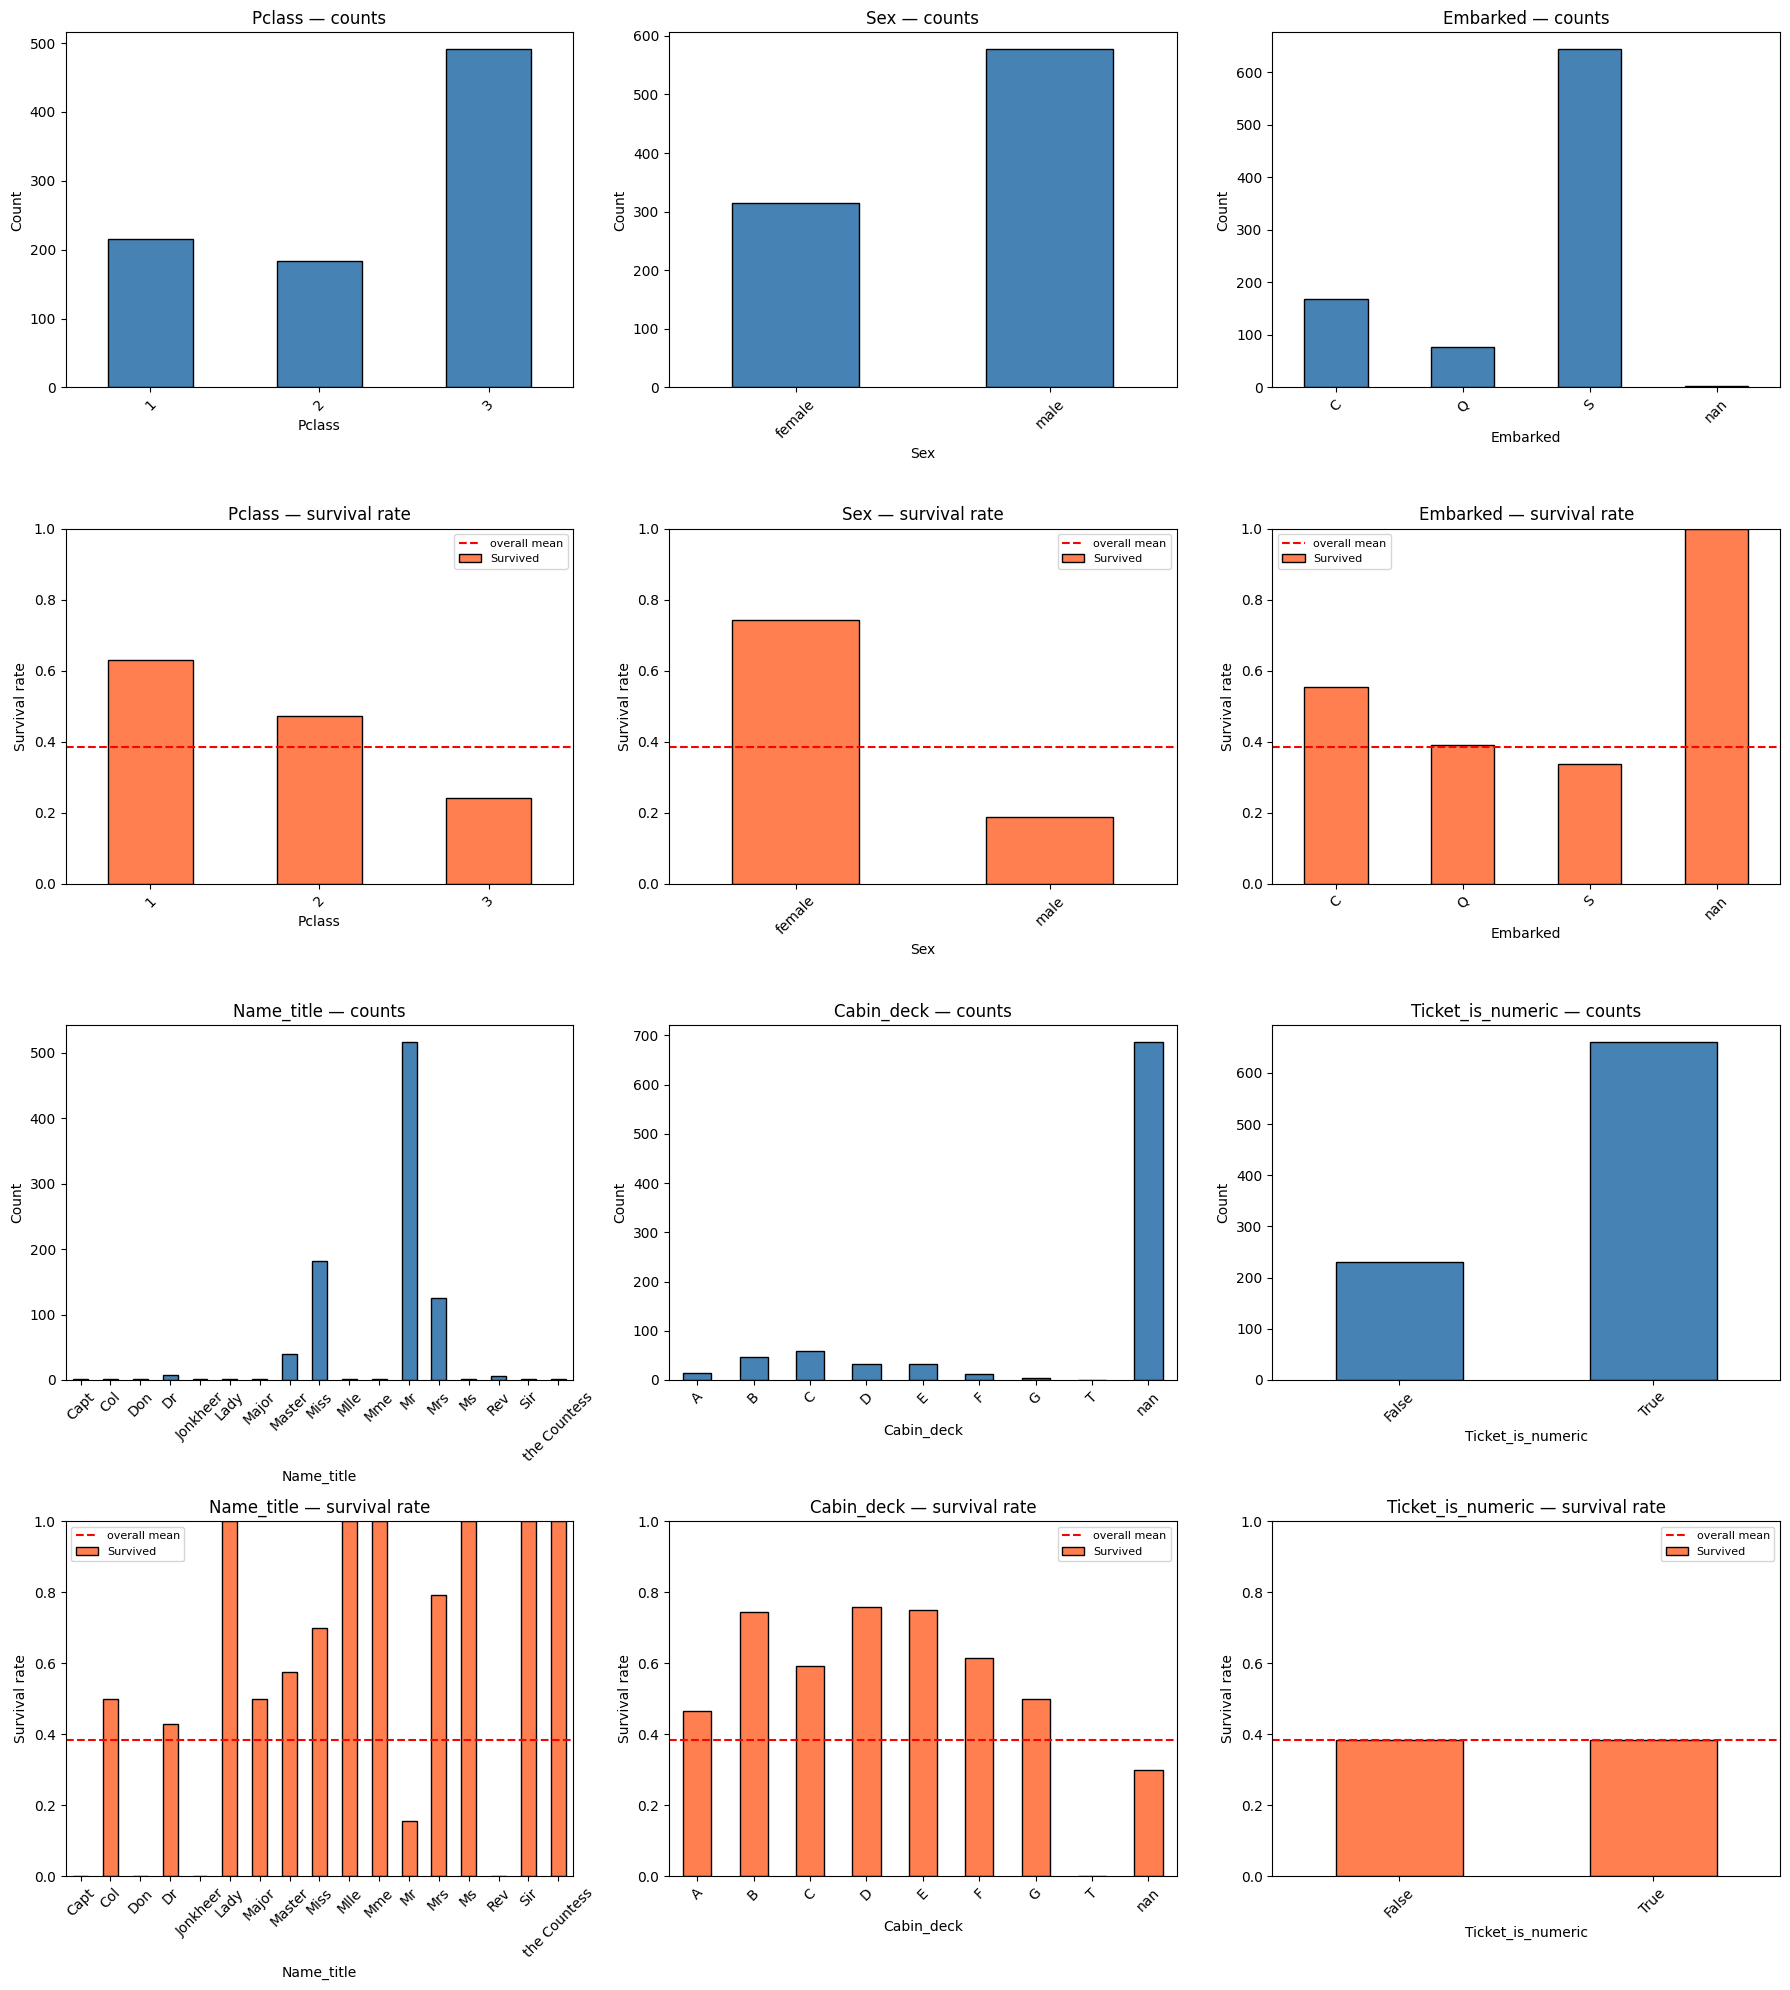

In [16]:
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Name_title', 'Cabin_deck', 'Ticket_is_numeric']

fig, axes = plt.subplots(4, 3, figsize=(18, 20))

for i, col in enumerate(cat_cols):
    row_uni  = (i // 3) * 2        # univariate row:     0 for first 3 cols, 2 for last 3
    row_surv = (i // 3) * 2 + 1   # survival rate row:  1 for first 3 cols, 3 for last 3
    col_idx  = i % 3

    # Univariate — raw value counts
    counts = df[col].value_counts(dropna=False).sort_index()
    counts.plot(kind='bar', ax=axes[row_uni, col_idx], color='steelblue', edgecolor='black')
    axes[row_uni, col_idx].set_title(f'{col} — counts')
    axes[row_uni, col_idx].set_ylabel('Count')
    axes[row_uni, col_idx].tick_params(axis='x', rotation=45)

    # Survival rate by category
    survival_rate = df.groupby(col, dropna=False)['Survived'].mean().sort_index()
    survival_rate.plot(kind='bar', ax=axes[row_surv, col_idx], color='coral', edgecolor='black')
    axes[row_surv, col_idx].set_title(f'{col} — survival rate')
    axes[row_surv, col_idx].set_ylabel('Survival rate')
    axes[row_surv, col_idx].set_ylim(0, 1)
    axes[row_surv, col_idx].axhline(df['Survived'].mean(), color='red', linestyle='--', label='overall mean')
    axes[row_surv, col_idx].legend(fontsize=8)
    axes[row_surv, col_idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Train / Test Split

In [17]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')
print(f'Train survival rate: {y_train.mean():.2%}')
print(f'Test survival rate:  {y_test.mean():.2%}')

Train size: 712
Test size:  179
Train survival rate: 38.34%
Test survival rate:  38.55%


## 7. Handle Nulls & Encode

In [18]:
# Drop raw high-cardinality columns — helpers extracted from them are kept
X_train = X_train.copy().drop(columns=['Name', 'Ticket', 'Cabin'])
X_test  = X_test.copy().drop(columns=['Name', 'Ticket', 'Cabin'])

print('Remaining columns:', list(X_train.columns))
print('Nulls in train:\n', X_train.isnull().sum()[X_train.isnull().sum() > 0])

Remaining columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Name_title', 'Ticket_is_numeric', 'Cabin_deck']
Nulls in train:
 Age           137
Embarked        2
Cabin_deck    552
dtype: int64


### Impute Numerical — median (fit on train only)

### Impute Categorical — mode (fit on train only)

In [19]:
# Age only — Fare, SibSp, Parch have no nulls
# Using median — Age is right-skewed so median is more robust than mean
age_median = X_train['Age'].median()
X_train['Age'] = X_train['Age'].fillna(age_median)
X_test['Age']  = X_test['Age'].fillna(age_median)

print(f'Age imputed with train median: {age_median}')
print('Nulls remaining (numerical):', X_train[['Age', 'Fare', 'SibSp', 'Parch']].isnull().sum().sum())

Age imputed with train median: 28.5
Nulls remaining (numerical): 0


In [20]:
# Embarked: 2 nulls — mode impute
embarked_mode = X_train['Embarked'].mode()[0]
X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_test['Embarked']  = X_test['Embarked'].fillna(embarked_mode)

# Cabin_deck: 77% nulls — treat as own 'Unknown' category rather than imputing with mode
X_train['Cabin_deck'] = X_train['Cabin_deck'].fillna('Unknown')
X_test['Cabin_deck']  = X_test['Cabin_deck'].fillna('Unknown')

# Name_title: no nulls — nothing to impute
print(f'Embarked imputed with train mode: {embarked_mode!r}')
print('Nulls remaining (categorical):', X_train[['Sex', 'Embarked', 'Name_title', 'Cabin_deck']].isnull().sum().sum())

Embarked imputed with train mode: 'S'
Nulls remaining (categorical): 0


### Encode Categoricals

In [21]:
encode_cols = ['Sex', 'Embarked', 'Name_title', 'Cabin_deck']
X_train = pd.get_dummies(X_train, columns=encode_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=encode_cols, drop_first=True)

# Align columns — get_dummies can produce different columns if a category only appears in one split
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f'Features ({len(X_train.columns)}): {list(X_train.columns)}')
print('Total nulls:', X_train.isnull().sum().sum())

Features (30): ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Ticket_is_numeric', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Name_title_Don', 'Name_title_Dr', 'Name_title_Jonkheer', 'Name_title_Lady', 'Name_title_Major', 'Name_title_Master', 'Name_title_Miss', 'Name_title_Mlle', 'Name_title_Mr', 'Name_title_Mrs', 'Name_title_Ms', 'Name_title_Rev', 'Name_title_Sir', 'Cabin_deck_B', 'Cabin_deck_C', 'Cabin_deck_D', 'Cabin_deck_E', 'Cabin_deck_F', 'Cabin_deck_G', 'Cabin_deck_T', 'Cabin_deck_Unknown']
Total nulls: 0


### Scale Numerical — fit on train only

In [22]:
num_cols_to_scale = ['Age', 'Fare', 'SibSp', 'Parch']

scaler = StandardScaler()
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale]  = scaler.transform(X_test[num_cols_to_scale])

print('Scaled columns:', num_cols_to_scale)
print(X_train[num_cols_to_scale].describe().round(3))

Scaled columns: ['Age', 'Fare', 'SibSp', 'Parch']
           Age     Fare    SibSp    Parch
count  712.000  712.000  712.000  712.000
mean     0.000   -0.000   -0.000   -0.000
std      1.001    1.001    1.001    1.001
min     -2.238   -0.663   -0.465   -0.466
25%     -0.581   -0.498   -0.465   -0.466
50%     -0.081   -0.362   -0.465   -0.466
75%      0.495   -0.017    0.478   -0.466
max      3.875   10.005    7.082    6.698


## 8. Build Random Forest

In [23]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print('Model trained.')

Model trained.


## 9. Evaluate

In [24]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

ROC-AUC: 0.8282

              precision    recall  f1-score   support

Not Survived       0.81      0.85      0.83       110
    Survived       0.75      0.68      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



In [25]:
# Stratified 5-fold CV on full dataset — preserves class ratio in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

cv_scores = cross_val_score(rf, X_full, y_full, cv=skf, scoring='roc_auc')
print(f'Stratified 5-fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold scores: {[round(s, 4) for s in cv_scores]}')

Stratified 5-fold CV ROC-AUC: 0.8741 ± 0.0210
Per-fold scores: [np.float64(0.8605), np.float64(0.9075), np.float64(0.8447), np.float64(0.8803), np.float64(0.8775)]


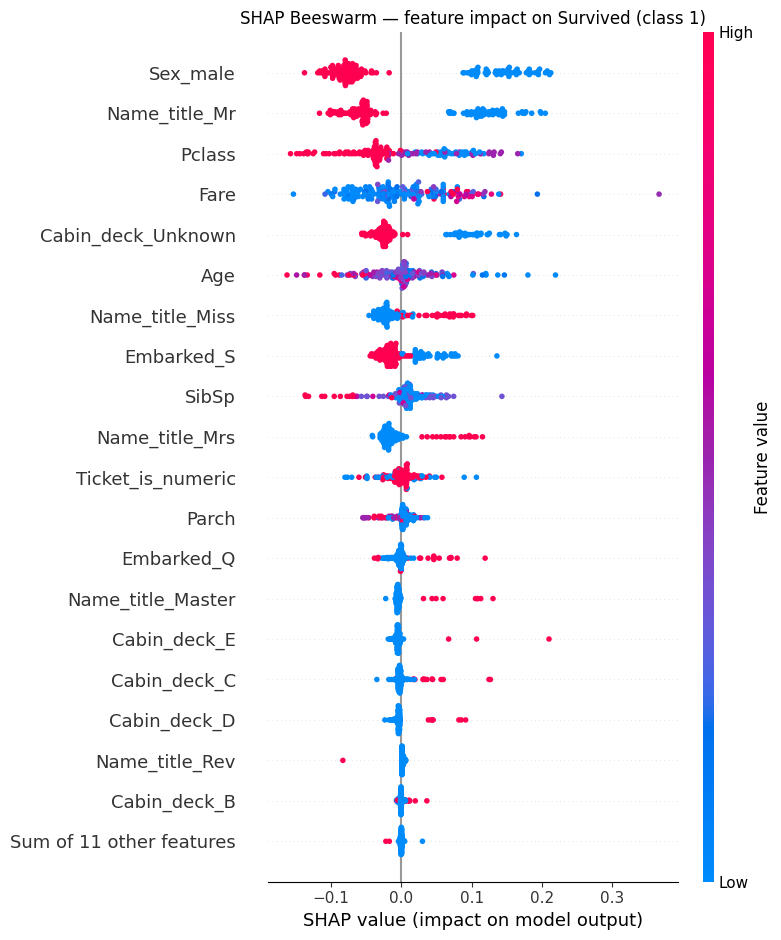

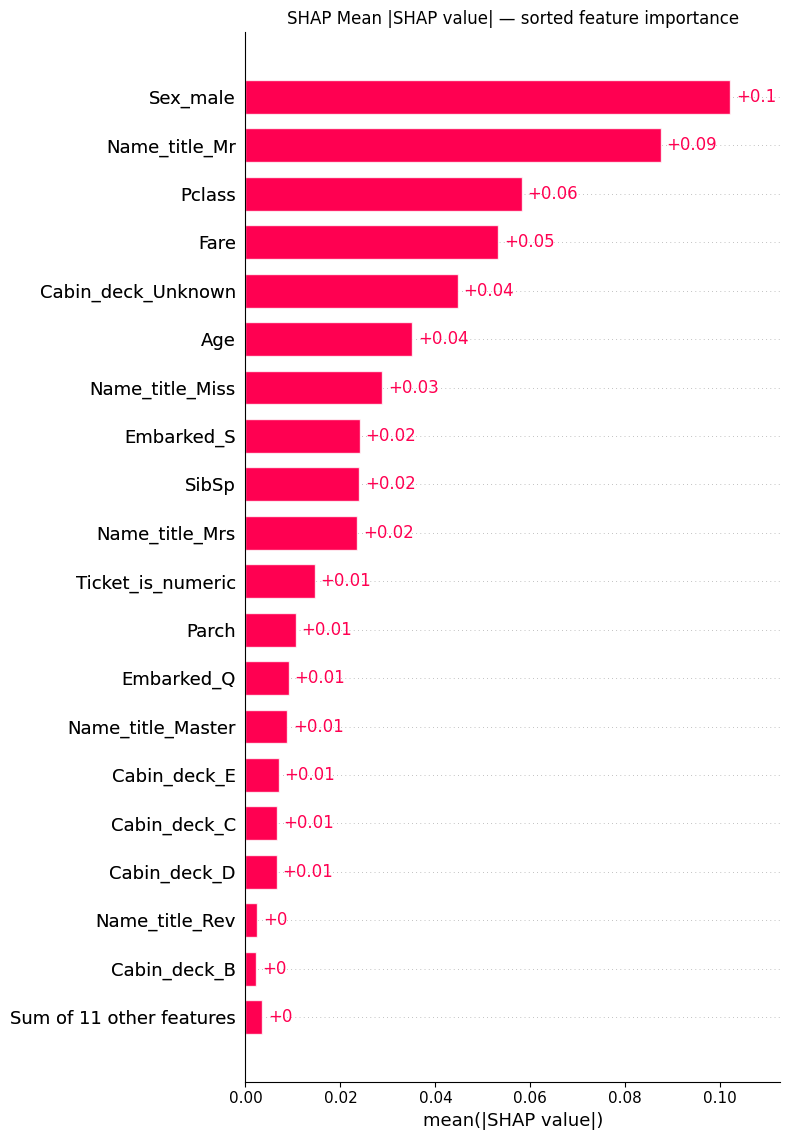

In [26]:


explainer   = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

# For binary classification TreeExplainer returns an Explanation object with shape (n, features, 2)
# Slice class 1 (Survived)
sv = shap_values[..., 1]

# --- Beeswarm plot ---
# Each dot = one passenger. x-axis = SHAP value (impact on prediction).
# Colour = feature value (red = high, blue = low).
shap.plots.beeswarm(sv, max_display=20, show=False)
plt.title('SHAP Beeswarm — feature impact on Survived (class 1)')
plt.tight_layout()
plt.show()

# --- Bar plot (mean |SHAP|) sorted ---
# Shows overall feature importance ranked by mean absolute contribution.
shap.plots.bar(sv, max_display=20, show=False)
plt.title('SHAP Mean |SHAP value| — sorted feature importance')
plt.tight_layout()
plt.show()